In [1]:
import pandas as pd
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, KFold
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.insert(0, "../utils")

from modules import *

enc = 'utf-8'

In [2]:
df_extnord = pd.read_csv(f'../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)
df_nord = pd.read_csv(f'../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

dataframe = pd.concat([df_extnord, df_nord], ignore_index=True)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

In [4]:
dataframe.head()

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,...,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,...,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,...,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,...,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,...,4,41,0,3,0,3,0,0,0,0


In [5]:
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

In [6]:
dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [7]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [8]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [9]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [10]:
risk_classes = list(range(1,10))
risk_classes

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [11]:
data_0 = dataframe.loc[dataframe['cases'] == 0].copy()
data_0.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
45,"(extreme nord, diamare, meri, meftek ouazzang)",14.102330,10.659593,2014-10,-0.866,0.5,0.351294,0.040027,-0.318706,-0.040027,...,28.33,1510.0,501.0,0.0,135.79,1168.0,1.0,84.0,1168.0,0
48,"(extreme nord, diamare, pette, djaoude)",14.487712,11.075133,2014-10,-0.866,0.5,0.383395,0.001750,-0.371906,-0.001750,...,27.67,1248.0,518.0,0.0,153.82,1007.0,0.0,70.0,797.0,0
49,"(extreme nord, diamare, pette, doubbel)",14.493886,10.858426,2014-10,-0.866,0.5,0.287341,-0.010931,-0.311673,0.010931,...,28.00,1372.0,494.0,0.0,143.16,1093.0,0.0,113.0,905.0,0
51,"(extreme nord, diamare, pette, malam petel)",14.442810,10.797340,2014-10,-0.866,0.5,0.349485,0.001638,-0.363086,-0.001638,...,28.33,1404.0,493.0,0.0,141.87,1117.0,0.0,117.0,912.0,0
66,"(extreme nord, logone et chari, kousseri, ngod...",14.966805,11.383706,2014-10,-0.866,0.5,0.394335,0.355255,0.103845,-0.355255,...,22.33,1404.0,473.0,0.0,134.85,1043.0,0.0,185.0,9.0,0


In [12]:
data_0['case_bin'] = 0

In [13]:
data_rest = dataframe.loc[dataframe['cases'] != 0].copy()
data_rest.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [14]:
bins, bounds = pd.qcut(x = data_rest.loc[:, 'cases'], q = 10-1, labels=risk_classes, retbins=True, precision=0)

In [15]:
data_rest['case_bin'] = bins

In [16]:
dataset = pd.concat([data_0, data_rest])

In [17]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [18]:
bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1   13   27   45   67   97  140  203  329 8022]


In [19]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

[Text(0, 0, '0'),
 Text(1, 0, '[1-13]'),
 Text(2, 0, '(13-27]'),
 Text(3, 0, '(27-45]'),
 Text(4, 0, '(45-67]'),
 Text(5, 0, '(67-97]'),
 Text(6, 0, '(97-140]'),
 Text(7, 0, '(140-203]'),
 Text(8, 0, '(203-329]'),
 Text(9, 0, '330+')]

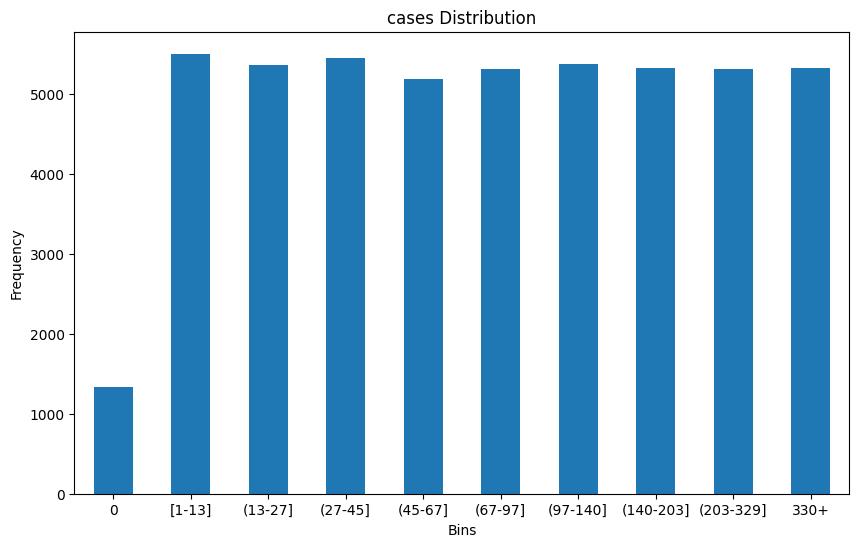

In [20]:
target_col = 'cases'

ax = dataset['case_bin'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title=f'{target_col} Distribution',
    xlabel='Bins',
    ylabel='Frequency'
)

# Set custom x-axis tick labels
ax.set_xticklabels(['0', '[1-13]', '(13-27]', '(27-45]','(45-67]','(67-97]','(97-140]','(140-203]','(203-329]','330+'], rotation=0) 
        

In [21]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94,5
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7,1
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91,5
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31,3
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49479,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-06,0.000,-1.0,0.513966,0.190414,-0.397487,-0.190414,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,66,4
49480,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-06,0.000,-1.0,0.402476,0.101305,-0.347630,-0.101305,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,140,6
49481,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-06,0.000,-1.0,0.450903,0.092213,-0.381622,-0.092213,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,708,9
49482,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-06,0.000,-1.0,0.454325,0.093292,-0.384450,-0.093292,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,408,9


In [22]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49484 entries, 0 to 49483
Data columns (total 70 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   location                 49484 non-null  object   
 1   x                        49484 non-null  float64  
 2   y                        49484 non-null  float64  
 3   dt_prediction            49484 non-null  period[M]
 4   month_sin                49484 non-null  float64  
 5   month_cos                49484 non-null  float64  
 6   ndvi                     49392 non-null  float64  
 7   ndmi                     49392 non-null  float64  
 8   ndwi                     49392 non-null  float64  
 9   ndbi                     49392 non-null  float64  
 10  ndvi_mean                49457 non-null  float64  
 11  ndmi_mean                49457 non-null  float64  
 12  ndwi_mean                49457 non-null  float64  
 13  ndbi_mean                49457 non-null  float

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

In [24]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['x', 'y', 'cases', 'case_bin'])
y = dataset['case_bin']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
# scaler = MinMaxScaler(feature_range = (-1, 1))
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [27]:
imputer = KNNImputer(n_neighbors=3)
imputer.fit(X_train)
X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [28]:
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

In [29]:
X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

In [30]:
model_params = {
    'objective': 'reg:absoluteerror',
    'eval_metric': 'mae', 
    'max_depth': 10,
    'learning_rate': 0.3,
    'n_estimators': 300, 
    'min_child_weight': 3,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'random_state': 0
}

In [31]:
model = xgb.XGBRegressor(**model_params)  

In [32]:
fitted_model = model.fit(X_train_imputed, y_train)

In [33]:
y_train_proba = fitted_model.predict(X_train_imputed)
y_test_proba = fitted_model.predict(X_test_imputed)

In [34]:
y_train_pred = np.clip(np.round(y_train_proba), 0, 9).astype(int)
y_test_pred = np.clip(np.round(y_test_proba), 0, 9).astype(int)

In [35]:
results_train = pd.DataFrame({'actual': y_train,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [36]:
metrics(results_train, results_test, threshold=1)

MAE on train set: 0.3800
MSE on train set: 0.6781
min prediction: 0
max prediction: 9

MAE on test set: 1.0722
MSE on test set: 2.1883
Error <= 1: 73.19 %
min prediction: 0
max prediction: 9


In [41]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mae',
    title='MAE per Risk Class'
)

In [42]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_prediction',
    group_by='month',
    metric='mae',
    title='Monthly MAE'
)

In [43]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_temp',
    group_by='year',
    metric='mae',
    title='Yearly MAE'
)

In [44]:
plot_hist_plotly(results_test['actual'].cat.codes, results_test['prediction'])